### RallyRF  
*Cam Bitter, Sebastian Pantzer, Danny Smith*  
  
Accessible via [github.com/CamBitter/RallyRF](github.com/CamBitter/RallyRF)

### Abstract

For decades, the sport of Tennis has been meticulously analyzed. Its design naturally lends itself to the development of advanced metrics that serve to reduce complicated gameplay to an interaction of statistics. In this project we aim to take advantage of these metrics to successfully predict outcomes of professional tennis matches. We used an existing database, consisting of the majority of professional tennis matches played since the 1960’s. After cleaning the data, we engineered multiple feature sets of summary statistics based on previous match stats. We trained and tested a Random Forest model on each feature set and compared the results to other models, including another ensemble model--a Gradient-Boosted Decision Tree. In the end, we reached a match prediction accuracy of 63%, while other models reached slightly lower accuracy marks. While our results demonstrate a successful implementation of less complex machine learning algorithms, we are cognizant of potential performance ceilings due to data limitations.

### Introduction

The main motivation behind this project is to learn a more advanced ML technique (that still holds up in modern times) in great detail by building it from the ground up. Random forests are widely popular and effective at medium sized tabular data, and much more efficient than deep learning models.  

Tennis is a very hard sport to predict, with variables like mental state having huge implications on match outcome. By applying our custom random forest to a real-world prediction problem, we hope to learn about what affects the performance of the model we built and compare our model to research findings.  

The primary source we used was *Random forest model identifies serve strength as a key
predictor of tennis match outcome*, by Zijian Gao and Amanda Kowalczyk. They used the Jeff Sackmann tennis dataset (which we also used, more on that later). They used random forests to predict outcomes of tennis matches, as well as some other models. They found that the random forest model provided the highest accuracy, which gave us even more encouragement and enthusiam to build our own model and achieve similar performance as them. We based a lot of our data wrangling and feature generation on their paper, primarily regarding mean statistics over a historical time period for each player heading into the match. This made the paper a natural benchmark for evaluating our performance.

We also examined the work done in *Tennis Match Prediction using Machine Leanring*, a Stanford CS project by Ajay Krishna Amudan. Amudan used Jeffsackmann's ATP tennis dataset, and did slightly different work with the data features than Gao, focusing more on head-to-head features. We tried integrating some ideas from both projects in our random forest implementation, however many of the features created in this project were too complex for us to implement by the time we had found it. This is discussed more in the conclusion.

*Tennis match outcome prediction using machine learning and in-match statistics* (IEEE, 2024) examined similar algorithms, including Random Forests and Logistic Regression, on ATP data from 2000-2022. Their work highlights the importance of in-match statistics as predictors of performance. This is a very cool approach, predicting point by point the outcome of the match. Their model is able to adapt to the changing state of the game, and provide updated predictions throughout the course of the game. This would have been super cool to implement, but we decided to hone our focus on building a custom random forest rather than a more complicated tennis-specific model. We also are not sure where we would acquire data for this, as their citation is simply [atptour.com/en](https://atptour.com/en). Very insightful citation, wow!
  
Amudan, A. (2019). *Tennis Match Prediction using Machine Leanring*. Stanford University, CS229: Machine Learning. [https://cs229.stanford.edu/proj2019aut/data/assignment_308832_raw/26647696.pdf](https://cs229.stanford.edu/proj2019aut/data/assignment_308832_raw/26647696.pdf)  
  
Gao, Z., & Kowalczyk, A. (2021). Random forest model identifies serve strength as a key predictor of tennis match outcome. *Journal of Sports Analytics*, 7(4), 255–262. [https://doi.org/10.3233/jsa-200515](https://doi.org/10.3233/jsa-200515)

Gupta, Y., & Assaf, R. (2024). Tennis match outcome prediction using machine learning and in-match statistics. *IEEE Xplore*. [https://ieeexplore.ieee.org/document/10937526](https://ieeexplore.ieee.org/document/10937526)

### Values

*Users*  

This project can and may be used by a range of people, and affect even more. The chief users are likely players/coaches, and gamblers/people who engage in sports betting. Since this project uses information from a large number of tennis players, it is possible to affect those players without their knowledge.  

*Beneficiaries*  

It is likely the most effective use of this program is in sports betting, so those who benefit most may be people trying to beat conventional odds. However, individual players looking to learn what features and characteristics of play matter most will also be positively affected.  

*Victims* 

Those negatively affected by this project are parallels of the beneficiaries - gamblers and players. A powerful prediction tool can both hurt sports bettors without the tool, and give a false sense of security to those who do possess it.  
Additionally, accurate models can harm professional players, who could receive more scrutiny and pressure to perform.  
It is important to note these effects, both positive and negative, are relatively lofty. It is unlikely this specific tool will become popularized enough to have impacts at the scale discussed here.  

*Personal Stake* 

As a group, we have a few layers of personal connection to this project. Cam is an experienced tennis player, and follows the sport professionally as well as leads the club team at Middlebury. Sebastian, while less involved in tennis, is a member of the track team. Danny plays for the Club Quadball team, and dabbles in other sports, including tennis. Overall, every member of the group has some level of person interest and stake in statistics of athletics. Beyond the sport itself, we all have some academic background in statistics, and were interesting in developing these connections when implementing a Random Forest as a new ML technique.  

*Is the world better off for this project?*  

Realistically, not really. This project has arguably brought engagement in learning to at least the three of us, so in that sense it has had a positive impact. However, the effect may not go beyond that.

### The Data

We used [JeffSackmann's ATP Data Repository](https://github.com/jeffsackmann/tennis_atp). It contains ATP tennis match results spanning back to 1964, with tens of thousands of match data. It is freely available for non-commercial use under a [creative commons license](https://creativecommons.org/licenses/by-nc-sa/4.0/).

Each match contains many features, such as ace% for each player, surface type, # of break points faced, etc. The full list can be found [here](https://github.com/jeffsackmann/tennis_atp). 

Sackmann's data goes all the way back to the 1980s. However, since many of the older matches are incomplete from a statistic tracking perspective, and the style of play in tennis has shifted greatly in the past 30 years, we chose to only look at data from the year 2000 onward. Also, Sackmann keeps track of both doubles and singles matches. We are only using data from singles. Most of JeffSackmann's features are *post match* statistics, so we perform some data analysis to generate stats for each player prior to the match they are competing in. 

There are several ways to represent the data. We could have one row represent each match and use the raw values for each feature. This is kinda clunky and doesn't necessarily represent a head-to-head match well. Another method would be to use the difference in statistics, which would basically halve our feature count, reducing complexity and increasing training time. This would also better capture the competitive edge that one player has over the other. However, this does not work well with some features. For example, the difference in skill between a rank 900 player and a rank 1000 player is much, much less than the difference in skill between a rank 1 player and a rank 100 player. 

We also derived two features from the original features, `ace_vs_df` and `surface_win_pct` based on the literature discussed above.

These are what we believed would be the most insightful features. Raw (per-player) features capture absolute player attributes, while difference features encode the relative edge one player holds over the other:

| Feature | Type | Description |
|---|---|---|
| `p1_won` | Raw | 1 if player 1 won |
| `surface_hard` | Raw | 1 if match is on hard court |
| `surface_clay` | Raw | 1 if match is on clay |
| `surface_grass` | Raw | 1 if match is on grass |
| `p1_rank` | Raw | ATP ranking of player 1 |
| `p2_rank` | Raw | ATP ranking of player 2 |
| `p1_rank_points` | Raw | ATP ranking points of player 1 |
| `p2_rank_points` | Raw | ATP ranking points of player 2 |
| `p1_height` | Raw | Height of player 1 (cm) |
| `p2_height` | Raw | Height of player 2 (cm) |
| `age_diff` | Diff | Age difference (p1 − p2) in years |
| `surface_win_pct_diff` | Diff | Difference in win % on the current surface |
| `ace_vs_df_diff` | Diff | Difference in ace-to-double-fault ratio |
| `first_in_diff` | Diff | Difference in first-serve in % |
| `first_won_diff` | Diff | Difference in first-serve win % |
| `second_won_diff` | Diff | Difference in second-serve win % |
| `bp_saved_pct_diff` | Diff | Difference in break points saved % |
| `bp_converted_pct_diff` | Diff | Difference in break points converted % |
| `win_pct_diff` | Diff | Difference in overall match win % |
| `games_played_diff` | Diff | Difference in total games played (experience proxy) |

To build a dataset with these features from the original Jeffsackmann data, we created `build_dataset.py`. Inside the build function, we can simply edit the data returned per-row in the the build function. Pre-generating this dataset using `build_dataset.py` is essential, as generating match statistics during training would be extremely cost intensive to do. I'm sure we could do some caching to make it faster, but we only need to create our feature dataset once and we are done. Unless we want to edit the features, that is.

How it works: `build_dataset.py` first caches player's matches sorted by date for speedy lookups. Then for each match, it aggregates the previous 6 months of matches for each player, and computes mean statistics across those matches. It utilizes vectorized Pandas functions for more speed. Then, we either return the raw feature value or the difference between both players, depending on the feature. `p1_won` is our target feature, and is computed based on `winner_name` from the original row.

Here is what the data looks like, stored in `some_diffs.csv`

In [41]:
import pandas as pd

df_some_diffs = pd.read_csv('data/cleaned/some_diffs.csv')
df_some_diffs.head(5)

,tourney_id,tourney_date,round,p1_name,p2_name,p1_won,surface_hard,surface_clay,surface_grass,p1_rank,...,age_diff,surface_win_pct_diff,ace_vs_df_diff,first_in_diff,first_won_diff,second_won_diff,bp_saved_pct_diff,bp_converted_pct_diff,win_pct_diff,games_played_diff
0,2000-338,20000110,R32,Adrian Voinea,Vincent Spadea,1,1,0,0,102.0,...,0.0,0.000000,1.400000,0.060928,0.153509,0.209459,0.514286,-1.000000,0.000000,0.0
1,2000-338,20000110,R32,Daniel Vacek,Jean Rene Lisnard,1,1,0,0,41.0,...,8.5,0.000000,0.400000,0.020263,-0.004918,-0.306265,-0.324405,0.114286,0.000000,0.0
2,2000-338,20000110,R32,Lleyton Hewitt,Sebastien Grosjean,1,1,0,0,21.0,...,-2.8,0.333333,-1.444444,0.001931,-0.022631,0.078335,-0.041667,-0.200000,0.333333,2.0
3,2000-338,20000110,R32,Slava Dosedel,Mark Woodforde,1,1,0,0,69.0,...,-4.8,0.500000,-0.333333,0.091800,0.040213,0.178623,-0.051136,0.000000,0.500000,1.0
4,2000-301,20000110,R32,Sjeng Schalken,Goran Ivanisevic,1,1,0,0,37.0,...,-5.0,0.666667,-0.781818,0.021985,0.025253,-0.056746,-0.214286,-0.687500,0.666667,2.0


Each match row is reversed, so we end up with twice as many rows as the original data we generated from.

In [42]:
df_some_diffs.shape

(123954, 25)

We end up with 123,954 rows to train on (61,977 matches).

We also decided to create two more datasets:
1. All raw feature values (`all_diffs.csv`)
2. All diff feature values (`no_diffs.csv`)

We wanted to see whether a combination of stat differences and raw values was actually beneficial to the model.

Here is what those look like:

In [43]:
df_no_diffs = pd.read_csv('data/cleaned/no_diffs.csv')
df_no_diffs.head(5)

,tourney_id,tourney_date,round,p1_name,p2_name,p1_won,surface_hard,surface_clay,surface_grass,p1_rank,...,p1_second_won,p2_second_won,p1_bp_saved_pct,p2_bp_saved_pct,p1_bp_converted_pct,p2_bp_converted_pct,p1_win_pct,p2_win_pct,p1_games_played,p2_games_played
0,2000-338,20000110,R32,Adrian Voinea,Vincent Spadea,1,1,0,0,102.0,...,0.459459,0.250000,0.800000,0.285714,0.0000,1.000000,0.000000,0.000000,1.0,1.0
1,2000-338,20000110,R32,Daniel Vacek,Jean Rene Lisnard,1,1,0,0,41.0,...,0.260000,0.566265,0.437500,0.761905,0.4000,0.285714,0.500000,0.500000,2.0,2.0
2,2000-338,20000110,R32,Lleyton Hewitt,Sebastien Grosjean,1,1,0,0,21.0,...,0.604651,0.526316,0.708333,0.750000,0.5500,0.750000,1.000000,0.666667,5.0,3.0
3,2000-338,20000110,R32,Slava Dosedel,Mark Woodforde,1,1,0,0,69.0,...,0.560976,0.382353,0.636364,0.687500,0.3750,0.375000,0.500000,0.000000,2.0,1.0
4,2000-301,20000110,R32,Sjeng Schalken,Goran Ivanisevic,1,1,0,0,37.0,...,0.486111,0.542857,0.500000,0.714286,0.3125,1.000000,0.666667,0.000000,3.0,1.0


In [44]:
df_all_diffs = pd.read_csv('data/cleaned/all_diffs.csv')
df_all_diffs.head(5)

,tourney_id,tourney_date,surface,round,p1_name,p2_name,p1_won,surface_hard,surface_clay,surface_grass,...,height_diff,surface_win_pct_diff,ace_vs_df_diff,first_in_diff,first_won_diff,second_won_diff,bp_saved_pct_diff,bp_converted_pct_diff,win_pct_diff,games_played_diff
0,2000-338,20000110,Hard,R32,Adrian Voinea,Vincent Spadea,1,1,0,0,...,2.0,0.000000,1.400000,0.060928,0.153509,0.209459,0.514286,-1.000000,0.000000,0.0
1,2000-338,20000110,Hard,R32,Daniel Vacek,Jean Rene Lisnard,1,1,0,0,...,17.0,0.000000,0.400000,0.020263,-0.004918,-0.306265,-0.324405,0.114286,0.000000,0.0
2,2000-338,20000110,Hard,R32,Lleyton Hewitt,Sebastien Grosjean,1,1,0,0,...,5.0,0.333333,-1.444444,0.001931,-0.022631,0.078335,-0.041667,-0.200000,0.333333,2.0
3,2000-338,20000110,Hard,R32,Slava Dosedel,Mark Woodforde,1,1,0,0,...,-5.0,0.500000,-0.333333,0.091800,0.040213,0.178623,-0.051136,0.000000,0.500000,1.0
4,2000-301,20000110,Hard,R32,Sjeng Schalken,Goran Ivanisevic,1,1,0,0,...,0.0,0.666667,-0.781818,0.021985,0.025253,-0.056746,-0.214286,-0.687500,0.666667,2.0


They have essentially the same features, just with different representations. They were generated by altering `build_dataset.py`, specifically the features returned in each row in the build function. It was also necessary to change the augmentation functionality as the features changed across datasets.

These datasets are also augmented to double our training size:

In [45]:
df_all_diffs.shape 

(123954, 23)

In [46]:
df_no_diffs.shape

(123954, 35)

Again, 123,954 rows to train on. Great!

Let's explore the data a bit.

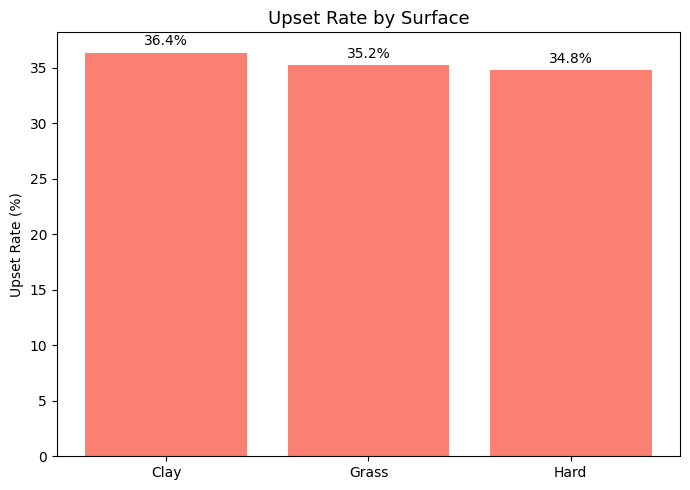

In [47]:
from matplotlib import pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(7, 5))

df = df_no_diffs[df_no_diffs['p1_won'] == 1].copy()
df['upset'] = df['p1_rank'] > df['p2_rank']

hard_upset = df[df['surface_hard'] == 1]['upset'].mean()
clay_upset = df[df['surface_clay'] == 1]['upset'].mean()
grass_upset = df[df['surface_grass'] == 1]['upset'].mean()

upset_by_surface = pd.Series({'Hard': hard_upset, 'Clay': clay_upset, 'Grass': grass_upset}).sort_values(ascending=False)

bars = ax.bar(upset_by_surface.index, upset_by_surface.values * 100, color='salmon')
ax.bar_label(bars, fmt='%.1f%%', padding=3)

ax.set_title('Upset Rate by Surface', fontsize=13)
ax.set_ylabel('Upset Rate (%)')

plt.tight_layout()
plt.show()


Here we see that upsets are slightly more likely on clay compared to grass, and slightly more likely on grass compared to hard courts.

This makes sense, as clay courts are more dynamic and less consistent than hard courts. Grass is similarly less consistent. Although, these percentages are so close that this may not be a statistically significant. 

Let's look at some more stats.

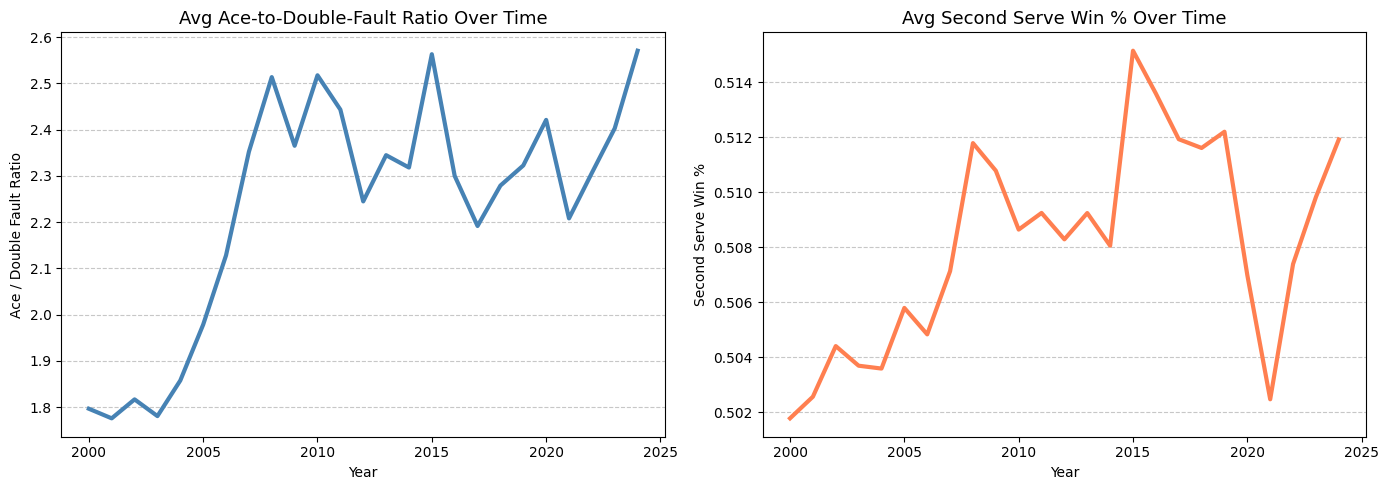

In [48]:
df = df_no_diffs.copy()
df['year'] = (df['tourney_date'] // 10000).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ace_vs_df over time
ace_by_year = df.groupby('year')[['p1_ace_vs_df', 'p2_ace_vs_df']].mean().mean(axis=1)
ax = axes[0]
ax.plot(ace_by_year.index, ace_by_year.values, color='steelblue', linewidth=3)
ax.set_title('Avg Ace-to-Double-Fault Ratio Over Time', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Ace / Double Fault Ratio')
ax.grid(axis='y', linestyle='--', alpha=0.7)

# second serve win % over time 
second_won_by_year = df.groupby('year')[['p1_second_won', 'p2_second_won']].mean().mean(axis=1)
ax = axes[1]
ax.plot(second_won_by_year.index, second_won_by_year.values, color='coral', linewidth=3)
ax.set_title('Avg Second Serve Win % Over Time', fontsize=13)
ax.set_xlabel('Year')
ax.set_ylabel('Second Serve Win %')
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

This is interesting! 

On the left, we see that the average ace to double fault ratio has increased over time. This means that players are serving more dominately and not getting "punished" for it with a high double fault ratio. This is consistent with more modern tennis, where serve speed and placement has improved significantly, making serve a bigger weapon than it was in the early 2000s. 

On the right, we see that second serve win % increased until the 2020 pandemic, after which it decreases rapidly. This drop in second serve win % may be due to the reduced match schedule, increasing variance. Or, perhaps players may have just gotten rusty without the normal match schedule. Nevertheless, its only a ~1% drop, so maybe not very significant regardless.

What about the best players in the game? 

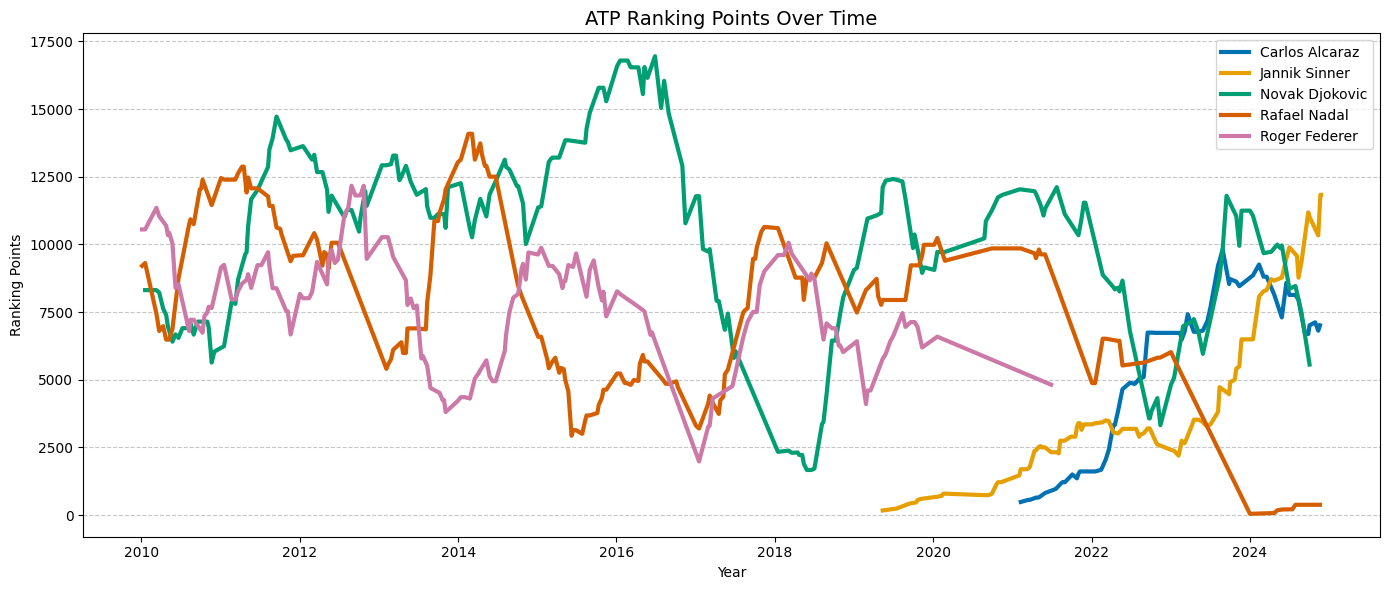

In [49]:
players = {
    'Carlos Alcaraz': '#0072B2',
    'Jannik Sinner': '#E69F00',
    'Novak Djokovic': '#009E73',
    'Rafael Nadal': '#D55E00',
    'Roger Federer': '#CC79A7',
}

df = df_no_diffs[df_no_diffs['tourney_date'] >= 20100101].copy() 

fig, ax = plt.subplots(figsize=(14, 6))

for player, color in players.items():
    # combine rows where player is p1 or p2, keeping date and rank points, then sort by date
    p1_rows = df[df['p1_name'] == player][['tourney_date', 'p1_rank_points']].rename(columns={'p1_rank_points': 'rank_points'})
    p2_rows = df[df['p2_name'] == player][['tourney_date', 'p2_rank_points']].rename(columns={'p2_rank_points': 'rank_points'})
    combined = pd.concat([p1_rows, p2_rows]).dropna()
    combined['date'] = pd.to_datetime(combined['tourney_date'].astype(str), format='%Y%m%d')
    combined = combined.sort_values('date').drop_duplicates('date')
    ax.plot(combined['date'], combined['rank_points'], label=player, color=color, linewidth=3)

ax.set_title('ATP Ranking Points Over Time', fontsize=14)
ax.set_xlabel('Year')
ax.set_ylabel('Ranking Points')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()


We can easily see the dominance of the Big 3 (Federer, Nadal, and Djokovic) from 2010 up until 2020. While this graph only has 5 players on it, it can be assured that no other players are even close to any of these throughout this entire time span in terms of ranking points. Right around 2020-2022 is when the Big 3 started to wind down, and we see the rise of Sinner and Alcaraz (the "New 2"). We see Sinner peeling ahead from Alcaraz in 2024, and today he remains ahead of Alcaraz.

Let's identify our base rate. The simplest method we could use is to just pick the higher ranked player, which is when p1_rank < p2_rank, or when rank_diff < 0:

In [50]:
test_df = df_all_diffs[df_all_diffs["tourney_date"] >= 20220101]
baseline = (test_df["rank_diff"] < 0).astype(float)
baseline_accuracy = (baseline == test_df["p1_won"]).mean()
print(f"Baseline Accuracy (Higher Seed Wins): {baseline_accuracy * 100:.2f}%")

Baseline Accuracy (Higher Seed Wins): 63.00%


We can see our baseline is 63%. Can we beat it?

# Our Approach 

Our project centered around the implementation of a random forest. However, we wanted to test several models to compare performance:

1. Random Forest — `random_forest.py`
2. Logistic Regression — `log_regression.py`
3. Shallow neural network — `mlp.py`
4. Gradient boosted decision tree — `boosted_tree.py` 


The goal of this project is to make predictions for future matches based on the past. Training our models on a match from 2017 and then testing them on a match from 2009 does not help us reach our goal of predicting future matches based on past performance. Thus, we decided to train on all matches from 2000 to 2022, and then test on 2022 to 2024 (the latest data at the time). 

We can use this time split to generate our test/train splits for all 3 datasets:


In [51]:
from src.features import FEATURE_SETS

feature_sets = ["some_diffs.csv", "no_diffs.csv", "all_diffs.csv"]

X_train_dict = {}
Y_train_dict = {}

X_test_dict = {}
Y_test_dict = {}

for feature_set in feature_sets:

    FEATURE_COLS = FEATURE_SETS[feature_set]
    df = pd.read_csv(f"data/cleaned/{feature_set}")

    # Split by date to avoid leakage — train on pre-2022, test on 2022+
    date_split = 20220101

    train_df = df[df["tourney_date"] < date_split]
    test_df  = df[df["tourney_date"] >= date_split]

    X_train_dict[feature_set] = train_df[FEATURE_COLS].to_numpy()
    Y_train_dict[feature_set] = train_df["p1_won"].to_numpy()

    X_test_dict[feature_set] = test_df[FEATURE_COLS].to_numpy()
    Y_test_dict[feature_set] = test_df["p1_won"].to_numpy()


print("Training samples:")
print(len(X_train_dict["some_diffs.csv"]), len(X_train_dict["no_diffs.csv"]), len(X_train_dict["all_diffs.csv"]))

print("Test samples:")
print(len(Y_test_dict["some_diffs.csv"]), len(Y_test_dict["no_diffs.csv"]), len(Y_test_dict["all_diffs.csv"]))

Training samples:
108526 108526 108526
Test samples:
15428 15428 15428


| Dataset | Feature Set |
|---|---|
| `some_diffs.csv` | As outlined in the Data section |
| `all_diffs.csv` | All features as differences (p1 − p2) |
| `no_diffs.csv` | All features as raw per-player values |

*Train/test split:* matches before 2022-01-01 for training, 2022-01-01 onward for testing.

*Hardware:* all models trained on personal laptops.

*Evaluation metrics:* accuracy, confidence scores, precision, recall, F1. Accuracy is the main metric since random forests have no loss function to optimize directly. 

**Decision Tree & Random Forest**

As our random forest is an ensemble model of invididual trees, we first needed to implement a single decision tree.

The core concept of a decision tree is pretty simple. Each node represents a variable threshold that we split along. Once we reach a leaf node, we will have our class prediction. The main functionality of a decision tree lies in how we decide what features and values to split our dataset along. 

We use the Gini Impurity, given by:

$$G = 1 - \sum_{i=1}^{n} p_i^{2}$$

Where $p_i$ is the proportion of samples belonging to class $i$.

Since we are performing binary classification, we can use the following:

$$G = 2p(1-p)$$

Where $p$ is the probability of one class.

Gini Impurity tells us how *impure* a set of data is. We can split on several values, and calculate the Gini Impurity of each to determine which split provides the highest purity in each subset of data. 

The split that provides largest increase in purity between subsets of data provides the most *information gain*, given by:

$$IG = G_{parent} - \sum_{j} \frac{n_j}{n} G_j$$

Where $n_j$ is the number of samples in child node $j$ and $n$ is the total samples in the parent. Note that we are weighting the Gini impurity of each node by relative size to the parent node, which gives us the *weighted information gain*. We value splits that reduce impurity across a large dataset, rather than niche splits that pick off one item at a time.

Again, since we are doing binary classification we can use the following:

$$IG = G_{parent} - \left(\frac{n_L}{n} G_L + \frac{n_R}{n} G_R\right)$$

Where $n_L$ is the number of samples in the left child node, and $n_R$ is the number of samples in the right child node.

Now, all we have to do is check many splits and choose the one that provides us the greatest information gain. Our initial implementation used an iterative process, which was extremely slow on large quantities of data and features. So, we switched to a vectorized approach instead which significantly reduced training time. It first sorts by feature value. Then, it takes a cumulative sum which gives the number of class 1 samples in positions 0 through n. This cumulative sum gives us the number of samples of class 1 if we split at position i, which we can then use in a vectorized operation to find the split that gives us the lowest Gini impurity value. This optimization reduces training time by over 95%. Very nice! Implementation can be found in `decision_tree.py:get_best_split()`

A random forest model uses many decision trees to form a prediction. Our implementation has:

- Data boostrapping $\rightarrow$ Each tree trains on a subset of data
- Feature bagging   $\rightarrow$ Each tree trains on a subset of features

We use data bootstrapping with replacement, meaning that trees may train on overlapping data. They may also train on overlapping features. 

The motivation behind this is the idea that a specific decision tree with boostrapped data and a random subset of features might be able to pick up on signals that a decision tree with a different subset of data and features wouldn’t. The random forest makes its prediction by polling each of the different decision trees and going with the outcome that receives the most votes. This also reduces overfitting.

We can associate a metric of confidence with each prediction of an observation, which is defined as the proportion of trees in the random forest that agree with the winning decision. A confidence score of 0.51 describes a prediction where the different trees were very divided in making their decision as a whole. 

The model has the following hyperparameters: 
- number of trees
- maximum-depth of each tree
- maximum amount of features used per tree

Tuning these parameters involves a balancing between underfitting, overfitting, and runtime complexity. But generally random forests perform very well without much hyperparameter fine tuning. 

We can go ahead and load in our compressed pickle model trained on the "some_diffs" dataset here:

In [52]:
import pickle
import gzip

n_trees = 150
max_depth = 20
max_features = 3

feature_set = "some_diffs.csv"

with gzip.open(f"models/forest-{feature_set[:-4]}-{n_trees}_trees-{max_depth}_depth-{max_features}_features.pkl.gz", "rb") as f:
    some_diffs_forest = pickle.load(f)


And we can go ahead and evaluate our train and test accuracy on "some_diffs.csv":

In [53]:
rf_test_preds_dict = {}
rf_confidence_dict = {}

X_train = X_train_dict["some_diffs.csv"]
Y_train = Y_train_dict["some_diffs.csv"]

X_test = X_test_dict["some_diffs.csv"]
Y_test = Y_test_dict["some_diffs.csv"]

Y_train_pred, _ = some_diffs_forest.predict(X_train)
Y_test_pred, Y_test_confidence = some_diffs_forest.predict(X_test)

# Training accuracy
train_accuracy = (Y_train_pred == Y_train).mean()
print(f"Training Accuracy: {train_accuracy * 100:.2f}%")

# Test accuracy
test_accuracy = (Y_test_pred == Y_test).mean()
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

rf_test_preds_dict["some_diffs.csv"] = Y_test_pred
rf_confidence_dict["some_diffs.csv"] = Y_test_confidence

Training Accuracy: 87.08%
Test Accuracy: 62.95%


Our model is relatively slow at making predictions since currently it recurses down each tree to make a single prediction(a future goal is to optimize this method, likely with vectorized operations and parallelization). For all_diffs and no_diffs, let's just check out the test accuracy:

In [54]:
with gzip.open(f"models/forest-no_diffs-{n_trees}_trees-{max_depth}_depth-{max_features}_features.pkl.gz", "rb") as f:
        no_diffs_forest = pickle.load(f)

with gzip.open(f"models/forest-all_diffs-{n_trees}_trees-{max_depth}_depth-{max_features}_features.pkl.gz", "rb") as f:
        all_diffs_forest = pickle.load(f)

for feature_set in ["no_diffs.csv", "all_diffs.csv"]:

    X_test = X_test_dict[feature_set]
    Y_test = Y_test_dict[feature_set]

    if feature_set == "no_diffs.csv":
        forest = no_diffs_forest
    else:      
        forest = all_diffs_forest
        
    Y_test_pred, Y_test_confidence = forest.predict(X_test)
    test_accuracy = (Y_test_pred == Y_test).mean()
    print(f"{feature_set[:-4]} Test Accuracy: {test_accuracy * 100:.2f}%")

    rf_test_preds_dict[feature_set] = Y_test_pred
    rf_confidence_dict[feature_set] = Y_test_confidence

no_diffs Test Accuracy: 62.88%
all_diffs Test Accuracy: 63.46%


Let's cherry pick a match to test our model.

Sinner and Alcaraz faced each other in 2024 in the China Open final. Let's check out our model's prediction:

In [55]:
for feature_set in feature_sets:

    X_test = X_test_dict[feature_set][7327]
    Y_test = Y_test_dict[feature_set][7327]

    if feature_set == "no_diffs.csv":
        forest = no_diffs_forest
    else:      
        forest = all_diffs_forest

    Y_test_pred, Y_test_confidence = forest.predict(X_test.reshape(1, -1))
    print(f"{feature_set[:-4]} — Prediction: {"Alcaraz" if Y_test_pred[0] else "Sinner"} | Confidence: {Y_test_confidence[0]:.4f} | Actual: {"Alcarz" if Y_test else "Sinner"}")

some_diffs — Prediction: Sinner | Confidence: 0.5267 | Actual: Alcarz
no_diffs — Prediction: Sinner | Confidence: 0.5867 | Actual: Alcarz
all_diffs — Prediction: Sinner | Confidence: 0.7067 | Actual: Alcarz


Unfortunately, we see all models predicting Alcaraz to lose, when he in fact won.

## 2: Logistic Regression
We also implemented a logistic regression model, commonly seen in class, to serve as a marginally more complex baseline. With a batch size of 128, we found that loss leveled off after 50 epochs. We used our custom derived gradient optimizer from class.

In [56]:
import torch
import numpy as np
from sklearn.preprocessing import StandardScaler
from src.log_regression import BinaryLogisticRegression, GradientDescentOptimizer, binary_cross_entropy

log_preds_dict = {}

for feature_set in feature_sets:
    X_train = X_train_dict[feature_set]
    Y_train = Y_train_dict[feature_set]
    X_test  = X_test_dict[feature_set]
    Y_test  = Y_test_dict[feature_set]

    scaler    = StandardScaler()
    X_train_t = torch.tensor(scaler.fit_transform(X_train), dtype=torch.float32)
    X_test_t  = torch.tensor(scaler.transform(X_test),      dtype=torch.float32)
    Y_train_t = torch.tensor(Y_train, dtype=torch.float32).unsqueeze(1)

    model = BinaryLogisticRegression(X_train_t.shape[1])
    opt   = GradientDescentOptimizer(model, lr=0.0001)

    batch_size = 128
    for epoch in range(50):
        perm = torch.randperm(len(X_train_t))
        for start in range(0, len(X_train_t), batch_size):
            idx = perm[start:start+batch_size]
            X_b, y_b = X_train_t[idx], Y_train_t[idx]
            binary_cross_entropy(model.forward(X_b), y_b, model)
            opt.step(X_b, y_b)


    with torch.no_grad():
        train_preds = (model.forward(X_train_t).squeeze() >= 0.5).float().numpy()
        test_preds  = (model.forward(X_test_t).squeeze()  >= 0.5).float().numpy()

    print(f"{feature_set} — Train accuracy: {(train_preds == Y_train).mean():.4f}")
    print(f"{feature_set} — Test accuracy:  {(test_preds  == Y_test).mean():.4f}\n")
    log_preds_dict[feature_set] = test_preds


some_diffs.csv — Train accuracy: 0.6584
some_diffs.csv — Test accuracy:  0.6335

no_diffs.csv — Train accuracy: 0.6580
no_diffs.csv — Test accuracy:  0.6335

all_diffs.csv — Train accuracy: 0.6585
all_diffs.csv — Test accuracy:  0.6337



## 3: Multilayer Perceptron / Shallow Neural Network
The MLP uses two hidden layers. We implemented an MLP to see how well a more complex model which is able to "learn" the features would perform. Logistic regression and trees don't "learn the features" per say, and we assumed that if the the MLP reacehs higher accuracy than either model then we would have to perform more feature engineering to meet the higher accuracy. 

We found our loss rounded off at about 15 epochs, optimized with Adam on binary cross entropy (BCE) loss. We can train 3 models on each dataset and store their predictions for later.

In [57]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from src.mlp import MLP
from torch.nn import BCELoss

mlp_test_preds_dict = {}
mlp_train_preds_dict = {}

for feature_set in feature_sets:
    FEATURE_COLS = FEATURE_SETS[feature_set]

    scaler  = StandardScaler()
    X_train = torch.tensor(scaler.fit_transform(X_train_dict[feature_set]), dtype=torch.float32)
    X_test  = torch.tensor(scaler.transform(X_test_dict[feature_set]),      dtype=torch.float32)
    Y_train = torch.tensor(Y_train_dict[feature_set], dtype=torch.float32)
    Y_test  = torch.tensor(Y_test_dict[feature_set],  dtype=torch.float32)


    dataset   = TensorDataset(X_train, Y_train)
    loader    = DataLoader(dataset, batch_size=128, shuffle=True)
    model     = MLP(input_size=len(FEATURE_COLS), hidden_size=128, output_size=1)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    loss_fn   = BCELoss()

    for epoch in range(15):
        total_loss = 0
        for X_batch, y_batch in loader:
            optimizer.zero_grad()
            loss = loss_fn(model(X_batch).squeeze(), y_batch)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

    model.eval()
    with torch.no_grad():
        train_acc = ((model(X_train).squeeze() >= 0.5).float() == Y_train).float().mean().item()
        test_acc = ((model(X_test).squeeze() >= 0.5).float() == Y_test).float().mean().item()
    
        print(f"{feature_set} — Train accuracy: {train_acc:.4f}")
        print(f"{feature_set} — Test accuracy:  {test_acc:.4f}\n")
        
        mlp_test_preds_dict[feature_set] = (model(X_test).squeeze() >= 0.5).float()
        mlp_train_preds_dict[feature_set] = (model(X_train).squeeze() >= 0.5).float()

some_diffs.csv — Train accuracy: 0.6701
some_diffs.csv — Test accuracy:  0.6434

no_diffs.csv — Train accuracy: 0.6784
no_diffs.csv — Test accuracy:  0.6406

all_diffs.csv — Train accuracy: 0.6683
all_diffs.csv — Test accuracy:  0.6384



## 4: Gradient Boosted Decision Tree
Lastly, we implemented a gradient boosted decision tree. Like random forests, boosted trees are an ensemble of decision trees. Simply put, boosted trees involve a sequential series of trees that learn from previous trees’ errors, or residuals. However, there is a big caveat worth discussion: our boosted tree model uses a regression decision tree, not classification like we've been using before. The main difference here is that when we calculate the value of leaf nodes of our trees, we return the mean value of the node instead of the value (zero or one) that is most popular. So, in effect, our trees predict a continuous value instead of a zero or one. Also, a regression tree calculates splits differently, using Variance Reduction instead of Gini Impurity. Variance Reduction is very similar to Gini Impurity, but differs in the sense that it tries to minimize the variance in each node instead of minimizing impurity, which we discussed above. Variance reduction is given by: $$\text{Variance Reduction} = \text{var}(\text{parent}) - \frac{n_L}{n}\cdot(\text{var}(\text{child}_L)) - \frac{n_R}{n}\cdot(\text{var}({\text{child}_R}))$$ Once again, where $n_L$ and $n_R$ are the number of observations in the left and right child nodes and $n$ is the number of observations in the parent node. The main idea is that the child nodes will contain values that are all very close to each other, but different than the values in the other child nodes, thus achieving a good split. 

Our boosted tree starts with an initial prediction for every observation: the average of our target variable, which is a probability. Boosted trees use a loss function: $$L = \frac{1}{2} \cdot (y_i - f(x_i))^2$$ where $y_i$ is the target variable, in this case, p1_won, $f(x_i)$ is the prediction, and $i$ corresponds to one observation in the data. When you take the negative derivative with respect to $f(x_i)$, you end up with: $$\frac{∂L}{∂f(x_i)} = y_i - f(x_i)$$ which is simply the residual of the prediction. Like gradient descent in linear regression, a new prediction is an update of the old prediction, moved in the direction of the negative derivative with respect to $y_i$. However, gradient descent in linear regression updates the weights of the model–here, we are adding a tree to update the prediction. In effect, this means that the next tree makes splits based on the residuals of the previous trees. The prediction of the entire ensemble is the sum of all of the predictions of the trees. Then, we put the prediction into the sigmoid function in order to get a probability value, $p$, between 0 and 1. Finally, we choose every $p$, above 0.5 to be a 1, and the rest, 0. We associated a different metric of confidence with the gradient boosted decision tree: $$\text{confidence} = 2\cdot| p - 0.5|$$ It’s important to note that this confidence score exists on a different scale than that of the random forest, because they encapsulate slightly different things. Our confidence score for boosted trees represents how much different the probability of predicting 1 was from 50%, multiplied by 2 to make it on a scale of $[0, 1]$, whereas confidence for the random forest reflects the majority vote proportion, which by nature must range from $(0.5, 1]$, assuming there’s no 50/50 split.

In [58]:
import time
from src.boosted_tree import BoostedTreeClassifier

n_trees = 10
max_depth = 5

boost_test_preds_dict = {}
boost_train_preds_dict = {}
boost_confidence_dict = {}

print("Fitting boosted trees...")
t0 = time.time()

for feature_set in feature_sets:
    X_train = X_train_dict[feature_set]
    Y_train = Y_train_dict[feature_set]
    X_test  = X_test_dict[feature_set]
    Y_test  = Y_test_dict[feature_set]

    boost = BoostedTreeClassifier(
        num_trees=n_trees,
        learning_rate=0.25,
        max_depth=max_depth,
        random_state=41,
        verbose=False,
    )
    boost.fit(X_train, Y_train.reshape(-1, 1))

    Y_train_pred, _, _ = boost.predict(X_train)
    Y_test_pred, Y_confidence, _ = boost.predict(X_test)

    train_acc = (Y_train_pred == Y_train).mean()
    test_acc  = (Y_test_pred  == Y_test).mean()

    print(f"{feature_set} — Train accuracy: {train_acc:.4f}")
    print(f"{feature_set} — Test accuracy:  {test_acc:.4f}\n")

    boost_test_preds_dict[feature_set] = Y_test_pred
    boost_train_preds_dict[feature_set] = Y_train_pred
    boost_confidence_dict[feature_set] = Y_confidence

print(f"Fit done in {time.time() - t0:.3f}s")


Fitting boosted trees...
some_diffs.csv — Train accuracy: 0.6715
some_diffs.csv — Test accuracy:  0.6374

no_diffs.csv — Train accuracy: 0.6732
no_diffs.csv — Test accuracy:  0.6376

all_diffs.csv — Train accuracy: 0.6697
all_diffs.csv — Test accuracy:  0.6357

Fit done in 27.235s


# Results  

### Random Forest

In [59]:
for feature_set in feature_sets:
    Y_test = Y_test_dict[feature_set]
    Y_pred = rf_test_preds_dict[feature_set]
    conf   = rf_confidence_dict[feature_set]

    test_acc = (Y_pred == Y_test).mean()

    print(f"{feature_set[:-4]}")
    print(f"  Test accuracy:   {test_acc:.4f}")
    print(f"  Min confidence:  {conf.min():.4f}")
    print(f"  Max confidence:  {conf.max():.4f}")
    print(f"  Mean confidence: {conf.mean():.4f}\n")


some_diffs
  Test accuracy:   0.6295
  Min confidence:  0.5000
  Max confidence:  0.9267
  Mean confidence: 0.6618

no_diffs
  Test accuracy:   0.6288
  Min confidence:  0.5000
  Max confidence:  0.8800
  Mean confidence: 0.6164

all_diffs
  Test accuracy:   0.6346
  Min confidence:  0.5000
  Max confidence:  0.9400
  Mean confidence: 0.6912



We see that the random forest doens't really achieve higher than our baseline on any of the feature sets, standing right around 63% across feature sets. However, we can still see some slight differences. `all_diffs` has the highest test accuracy (63.46%), as well as a fairly solid 0.6912 mean confidence. `no_diffs` is the worst performer, with the lowest test accuracy (62.88%) and the lowest mean confidence (0.6164). `some_diffs` comes in right in between the two, with 62.95% test accuracy and 0.6618 mean confidence.

Despite these differences though, these models essentially all have the same test accuracy, with `all_diffs` having a somewhat significant increase in confidence scores. 

Train accuracy can be found above during model loading.

Is there any difference between each dataset on the types of predictions they are making?

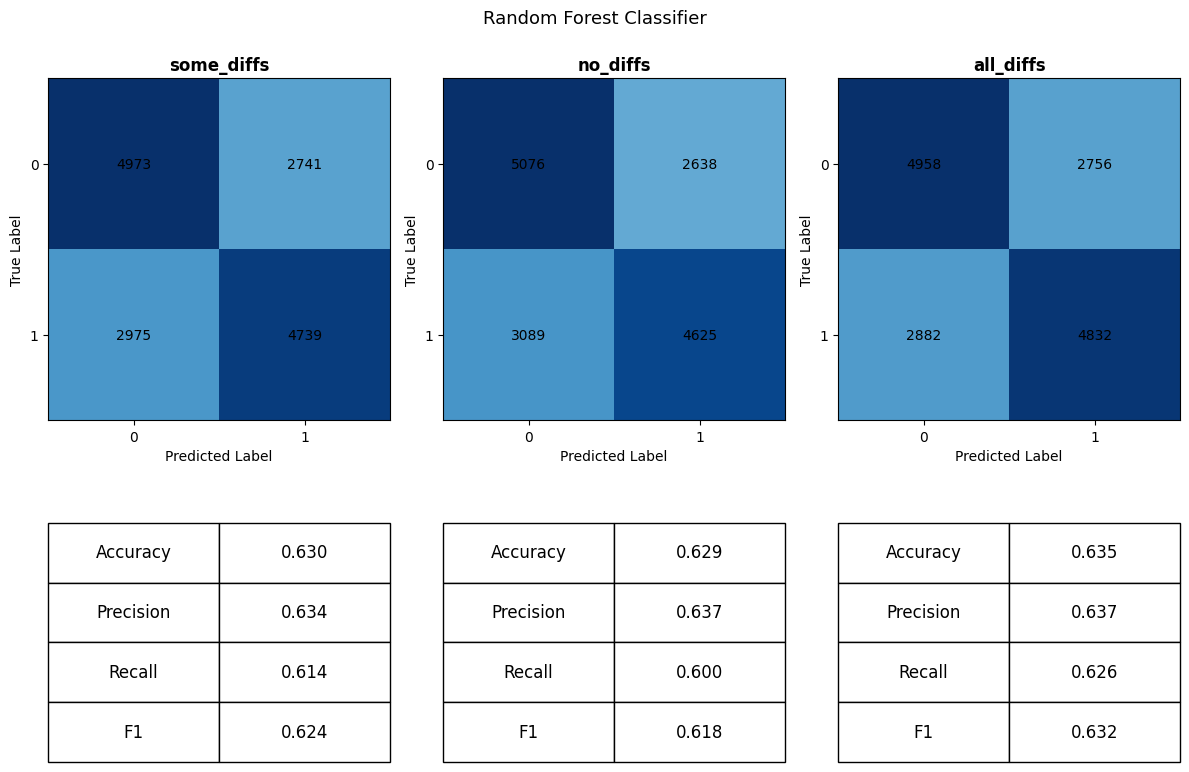

In [60]:
def plot_confusion_matrix(preds, true, ax, title):
    conf_mat = np.zeros((2, 2), dtype=int)
    for t, p in zip(true.flatten(), preds.flatten()):
        conf_mat[int(t), int(p)] += 1

    tn, fp = conf_mat[0, 0], conf_mat[0, 1]
    fn, tp = conf_mat[1, 0], conf_mat[1, 1]

    acc  = (tp + tn) / conf_mat.sum()
    prec = tp / (tp + fp)
    rec  = tp / (tp + fn)
    f1   = 2 * (prec * rec) / (prec + rec)

    ax.imshow(conf_mat, cmap="Blues", origin="upper", vmin=0)
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(["0", "1"])
    ax.set_yticklabels(["0", "1"])
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(False)

    for i in range(2):
        for j in range(2):
            ax.text(j, i, conf_mat[i, j].item(), ha="center", va="center", color="black", size=10)

    table_data = [
        ["Accuracy",  f"{acc:.3f}"],
        ["Precision", f"{prec:.3f}"],
        ["Recall",    f"{rec:.3f}"],
        ["F1",        f"{f1:.3f}"],
    ]
    table = ax.table(cellText=table_data, loc="bottom", cellLoc="center", bbox=[0, -1, 1, 0.7])
    table.auto_set_font_size(False)
    table.set_fontsize(12)


fig, axes = plt.subplots(1, len(feature_sets), figsize=(12, 7))
plt.subplots_adjust(bottom=0.35)

for ax, feature_set in zip(axes, feature_sets):
    plot_confusion_matrix(
        preds=rf_test_preds_dict[feature_set],
        true=Y_test_dict[feature_set],
        ax=ax,
        title=feature_set[:-4],
        vmin=0,
    )

plt.suptitle("Random Forest Classifier", fontsize=13)
plt.tight_layout()
plt.show()


We see darker colored corners corresponding to true negative and true positive, which is great! Our model is certainly learning something, as it is performing better than flipping a coin. Our accuracy across all feature sets is essentially 63%. 

We can see from the confusion matrices that they all generally predict losses in the same fashion. There is no abundance of false negatives or false positives. This is likely a byproduct of our data augmentation, where each match is flipped. This means that if we have one match where player 1 beats player 2, we also have the same match where player 2 loses to player 1. This should create symmetry between false positives and false negatives which we see in the confusion matrix.

Like our accuracies, our precision, recall, and F1 scores are pretty similar across the board, though once again `all_diffs` has slightly higher precision, recall, and F1 than `some_diffs` or `no_diffs`.

What's nice with using decision trees is that it is really easy to peel them apart and what they are using to make predictions.

The first split of each tree tells us the feature that gave the greatest information gain which should be the strongest predictor of who won a match.

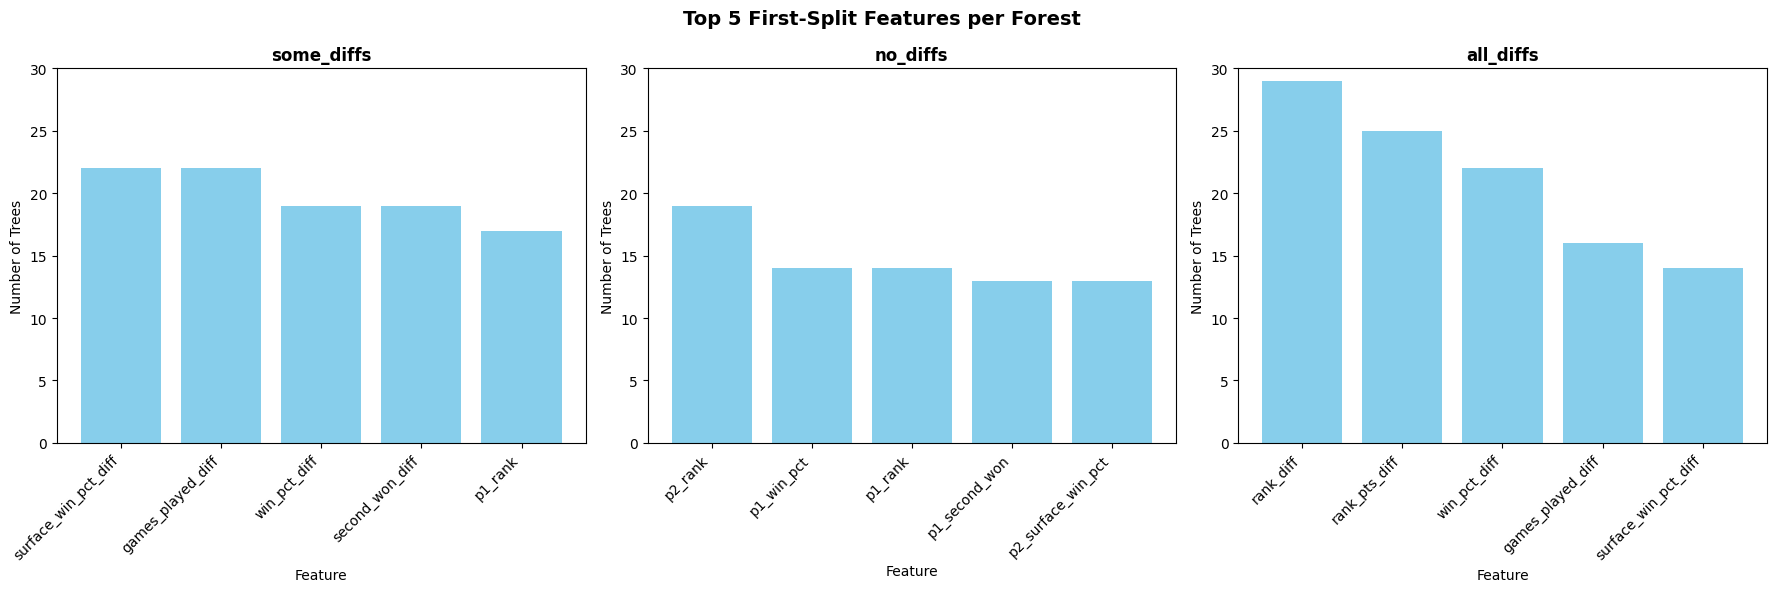

In [61]:
forest_map = {
    "some_diffs.csv": some_diffs_forest,
    "no_diffs.csv":   no_diffs_forest,
    "all_diffs.csv":  all_diffs_forest,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (feature_set, forest) in zip(axes, forest_map.items()):
    FEATURE_COLS = FEATURE_SETS[feature_set]

    counts = {}
    for tree, tree_feats in zip(forest.trees, forest.tree_features):
        name = FEATURE_COLS[tree_feats[tree.root.feature]]
        counts[name] = counts.get(name, 0) + 1

    top_5 = sorted(counts.items(), key=lambda x: x[1], reverse=True)[:5]
    names, values = zip(*top_5)

    ax.bar(names, values, color='skyblue')
    ax.set_title(feature_set[:-4], fontweight='bold')
    ax.set_xlabel('Feature')
    ax.set_ylabel('Number of Trees')
    ax.set_ylim(0, 30)
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

plt.suptitle('Top 5 First-Split Features per Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


Across all three forests, rank-based and overall win-rate features dominate the first splits, showing that a player's general standing and recent performance are the strongest single signals available to the model. 

It is really interesting to see that in `some_diffs`, surface win% and games played are more frequently the top split compared to win% and p1_rank. We also see that in `some_diffs`, second serve win% is frequently chosen as a first split, showing that players with have a strong second service game may be more likely to win. 

In `no_diffs`, rank and win% are the most frequently the first split feature. We also see second serve win% (for player 1) again. Seeing this aspect of the game repeated provides more claim that it is an important aspect of tennis which correlates with higher win rates. We also see surface win% as the 5th most frequent first split feature. While it is less frequent than general win%, seeing it in `some_diffs` and `all_diffs` does indicate that surface-specific win% is an important signal to predicting tennis matches.

In `all_diffs`, the top splits are similarly rank and win% differences. Here, we see `rank_diff` is the most split feature between all 3 feature sets. This aligns with our seed base rate, where predicting a higher seed yields ~64% accuracy, and `all_diffs` is the closest feature set to reaching this accuracy. 

An interesting note is that our hypothesis about using raw rank compared to rank diff does not appear accurate. `rank_diff` is the most frequent, highest information gain feature to split on. This highlights that comparing rank and predicting a higher seed is an extremely strong indicator of match outcome, and that our attempt to capture more rank nuance using raw scores was not as effective.

We can similarly look at which features are least frequently split on first. These features should be much less important in predicting tennis match outcomes. 

(Note that hard, grass, and clay court types are removed from feature pool as they are generally reliant on other aspects of a player's game and don't provide any meaningful information gain in the first split)

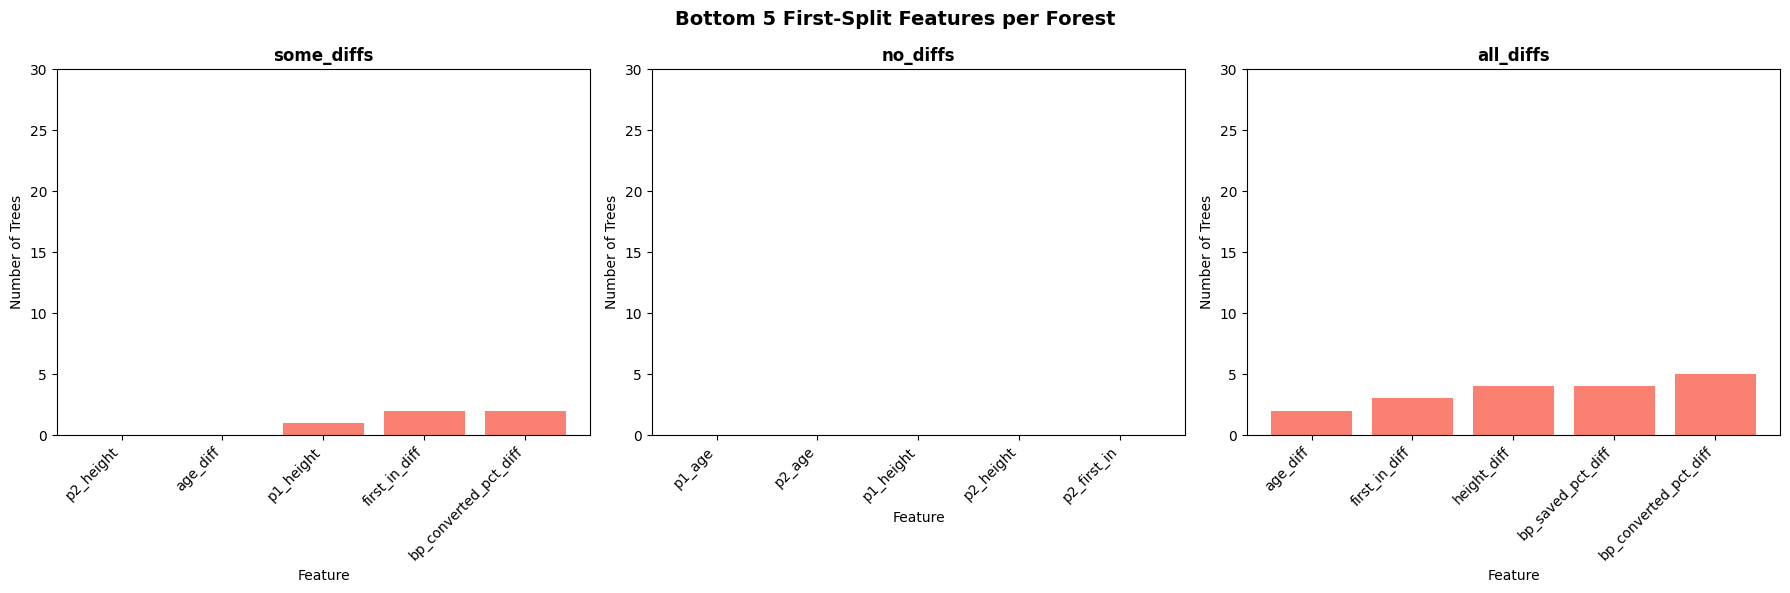

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for ax, (feature_set, forest) in zip(axes, forest_map.items()):
    FEATURE_COLS = FEATURE_SETS[feature_set]

    # Ignore surface types, which don't provide meaningful information gain as first splits
    counts = {name: 0 for name in FEATURE_COLS if not name.startswith("surface_")}
    for tree, tree_feats in zip(forest.trees, forest.tree_features):
        name = FEATURE_COLS[tree_feats[tree.root.feature]]
        if name.startswith("surface_"):
            continue
        counts[name] += 1

    bottom_5 = sorted(counts.items(), key=lambda x: x[1])[:5]
    names, values = zip(*bottom_5)

    ax.bar(names, values, color='salmon')
    ax.set_title(feature_set[:-4], fontweight='bold')
    ax.set_xlabel('Feature')
    ax.set_ylabel('Number of Trees')
    ax.set_ylim(0, 30)
    ax.tick_params(axis='x', rotation=45)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment('right')

plt.suptitle('Bottom 5 First-Split Features per Forest', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


We can see that across the board, age and height play a minimal role in predicting tennis match outcomes. While these features here seem unimportant, it is likely because their derivates are stronger indicators of performance. For example, if you are very tall, you have a huge serve advantage and likely win more matches because of it. Thus, your serve percentage becomes the important feature, rather than one factor of your serve.

Same thing with age. An older player may have more experience, or they may be weaker and less physically capable. Most of the other features are derivates of age and are better predictors of match performance, hence the low frequency of first splits.

In both `some_diffs` and `all_diffs`, we see break point conversion % difference as the 5th least frequent first split. This indicates that conversion of breakpoints are not a strong measure of predicting matches in our model on this data. This is interesting, as we would have thought that this feature incorporates some mental aspects of the game which we know is a key part of performance. However, it seems in this case to add little signal to the model. 

A similar story is going on with break point save % in `all_diffs`. How well you can save breakpoints indicates how well you can handle the pressure at an extremely important part of the match. Saving break point is an extremely important aspect of the game, and players who save just a fraction more break points will likely win many more matches. So, it's interesting to see that is provides little value here. One hypothesis is that our 6-month stat window is too large, and that players can have large mental swings during that time frame. Tennis is very much a mental game, and mental state can swing vastly even between service games. 6 months might dilute any meaning from this feature.

### Gradient Boosted Decision Tree

In [ ]:
rows = {}
for feature_set in feature_sets:
    Y_train      = Y_train_dict[feature_set]
    Y_test       = Y_test_dict[feature_set]
    Y_train_pred = boost_train_preds_dict[feature_set]
    Y_pred       = boost_test_preds_dict[feature_set]
    confidence   = boost_confidence_dict[feature_set]

    rows[feature_set[:-4]] = [
        (Y_train_pred == Y_train).mean(),
        (Y_pred == Y_test).mean(),
        confidence.max(),
        confidence.min(),
        confidence.mean(),
    ]

results = pd.DataFrame(rows, index=["Train Accuracy", "Test Accuracy", "Max Confidence", "Min Confidence", "Mean Confidence"])
results.style.format("{:.2%}")


,some_diffs,no_diffs,all_diffs
Train Accuracy,67.15%,67.32%,66.97%
Test Accuracy,63.74%,63.76%,63.57%
Max Confidence,22.87%,23.39%,22.74%
Min Confidence,0.00%,0.00%,0.00%
Mean Confidence,7.48%,7.18%,7.66%


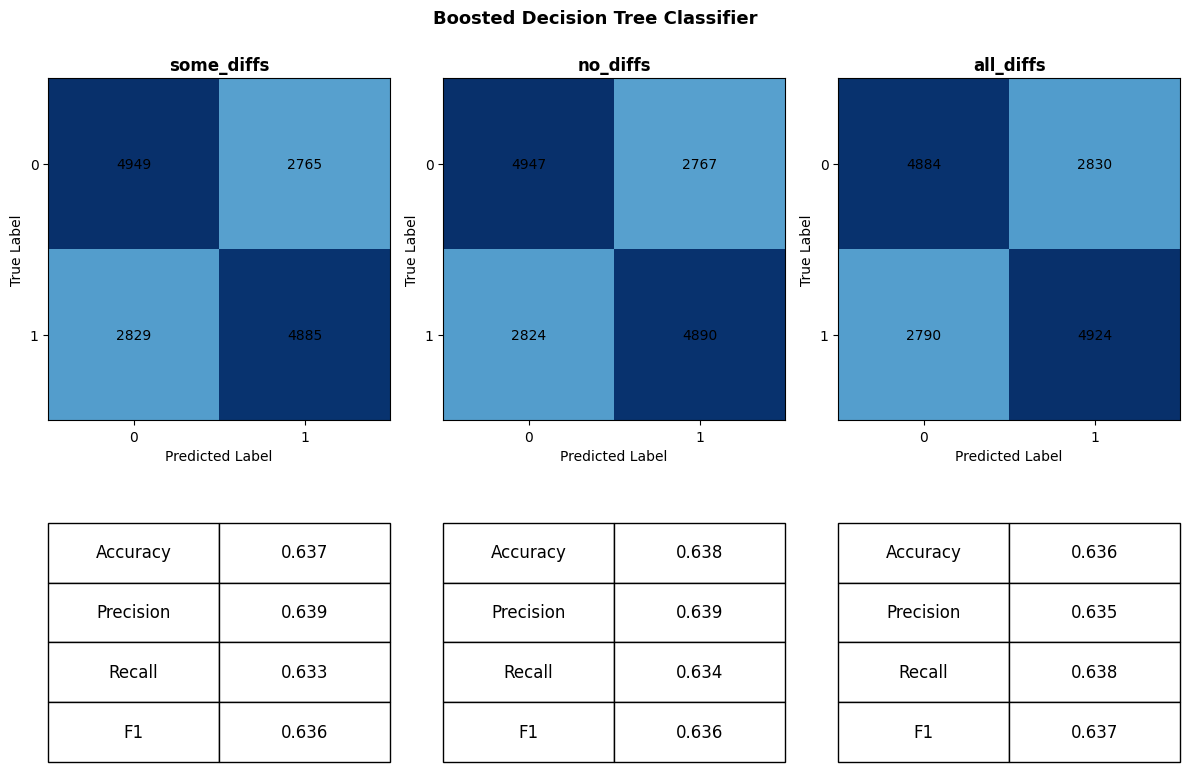

In [ ]:
ig, axes = plt.subplots(1, len(feature_sets), figsize=(12, 7))
plt.subplots_adjust(bottom=0.35)

for ax, feature_set in zip(axes, feature_sets):
    plot_confusion_matrix(
        preds=boost_test_preds_dict[feature_set],
        true=Y_test_dict[feature_set],
        ax=ax,
        title=feature_set[:-4],
        vmin=0,
    )

plt.suptitle("Boosted Decision Tree Classifier", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

Looking at our test accuracies for our Gradient Boosted Decision Trees, we see that the models achieved the same level of accuracy for each feature set. Looking at the confidences for each feature set, we see that the model is not very confident that a prediction is what it predicts it is. At best, they have a confidence score of about 0.2, which represents predicting about 60 percent chance of player 1 winning a match, or about 40 percent chance of a loss for player 1. At worst, the model was 0% confident. Looking at the confusion matrices, we see that the model has the same share of false negative and false positive for each feature set. Looking at the very similar precision and recall statistics, model seems to predict wins and losses at the same rate-- it isn't biased towards one or the other. In other words, false positives and false negatives occur at the same rate.

### Baseline: Logistic Regression: ###

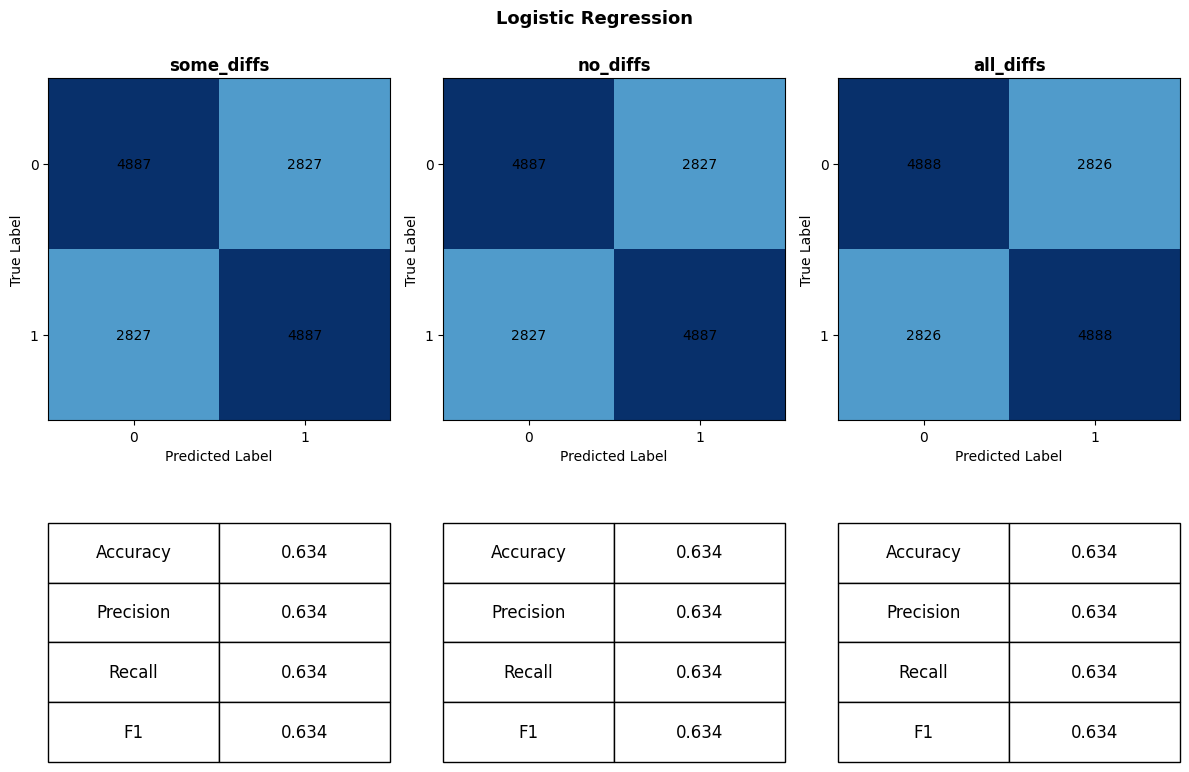

In [ ]:
fig, axes = plt.subplots(1, len(feature_sets), figsize=(12, 7))
plt.subplots_adjust(bottom=0.35)

for ax, feature_set in zip(axes, feature_sets):
    plot_confusion_matrix(
        preds=log_preds_dict[feature_set],
        true=Y_test_dict[feature_set],
        ax=ax,
        title=feature_set[:-4],
        vmin=0,
    )

plt.suptitle("Logistic Regression", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

As we can see, the accuracy of `63.4%` is the same as the `~64%` seed baseline. The precision, recall, and F1 score all being identical to the accuracy shows the model has found some features to determine with, but it predicting symmetric errors. We didn't expect Logistc Regression to perform well here, but the fact that it performs basically the same as the Random Forest and Gradient Boosted Tree indicates that our current feature set may not capture enough underlying signal to gain higher accuracy. 

### MLP ###

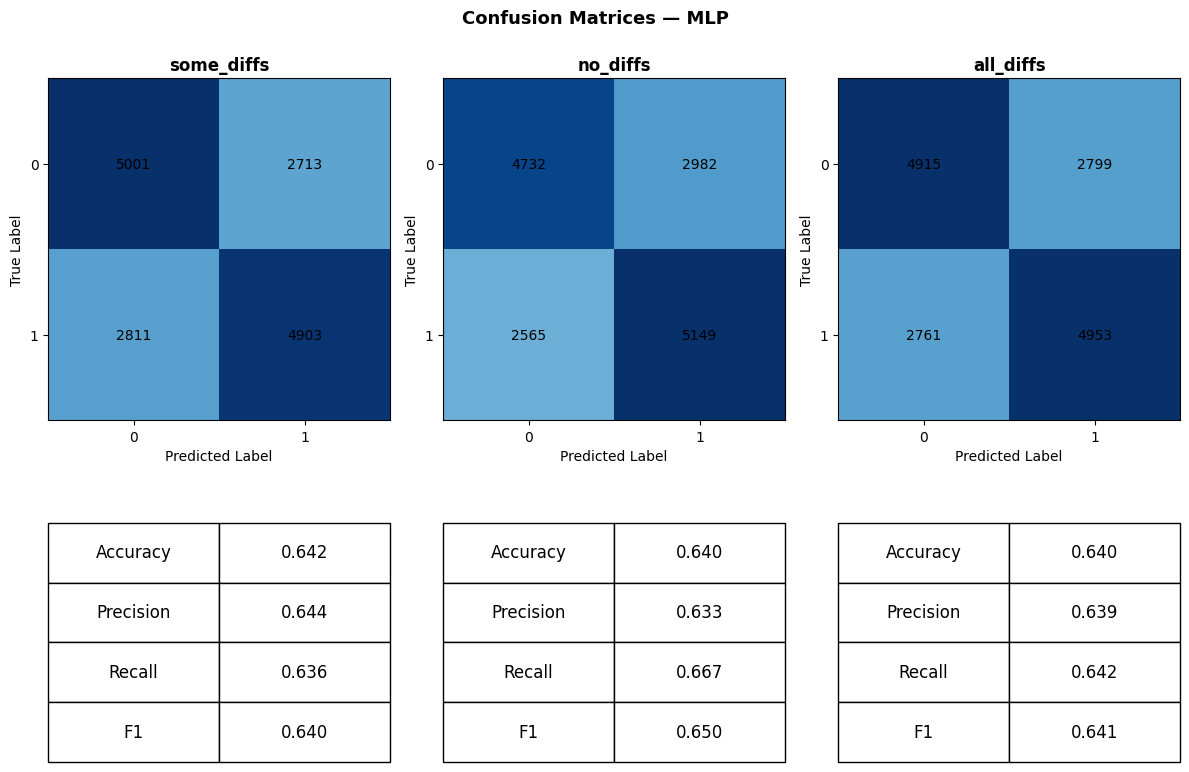

In [ ]:
fig, axes = plt.subplots(1, len(feature_sets), figsize=(12, 7))
plt.subplots_adjust(bottom=0.35)

for ax, feature_set in zip(axes, feature_sets):
    plot_confusion_matrix(
        preds=mlp_test_preds_dict[feature_set],
        true=Y_test_dict[feature_set],
        ax=ax,
        title=feature_set[:-4],
        vmin=0,
    )

plt.suptitle("Confusion Matrices — MLP", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


Even though it is a more complex model than the logistic regression, our multilayer perceptron only achieves `63.35%` accuracy, slightly lower than the logistic regression. The matrix shows that the MLP is correctly predicting losses a little bit more than wins. While the accuracy is just barely below the logistic regression, the the different Precision, Recall, and F1 scores suggest the MLP is making more meaningful distinctions between winning and losing. With more attention to features and data, the MLP model may be able to outperform the logistic regression. However, we were not able to achieve such results.

**Conclusion**  
  
In the end, our project was not able to reach the results we were hoping for based on the literature. While the Gao et al paper was able to achieve accuracy better than 80%, we were unable to pass 63-64%. There are several possible explanations for this. One could be that we were not using the data to its highest potential. 

We feel that this is somewhat unlikely, given that we used all features in the original data, derived our own new features based on the research, and test three different methods of representing the data. The Gao et. al paper did mention the use of ATP tour data, which we did not find cited or reference anywhere in the document, and were unable to locate any sort of public ATP data ourselves. We were limited to the Jeffsackmann data, which perhaps is where our accuracy deficiencies lie (although we are unsure). More evidence to support a lack of signal in the data is that our MLP, which aims to "learn" the features, provided no additional accuracies, even using the raw data. Surely a neural network would have picked up on additional features if they exited in the data? Or perhaps our model is too simple.

One thing we could have tried with more time would be to implement a custom elo system. A major flaw with using ATP ranking as a predictive variable is that it is cumulative over the season and does not represent recent data, but rather the entire previous year of performance. How it works is that once a player plays in a tournament, they earn points for their result. They keep these points for an entire year, when they must "defend" them by playing in the same tournament and finishing in the same round or better. Essentially, if Sinner accumulates 6000 ranking points between January and February, and then is injured from March to December, he will remain at 6000 rank points until next January. A custom elo system would be able to track more recent performance and provide a more accurate gauge of how players will perform in the near future.

Another reason our accuracy may be low is that our 6-month stat mean does not account for niche or recent performance very well. This could be why we are capped at the base rate of picking ranked players, because we are essentially only calculating each player's medium term performance. 6 months and the 1 year ranking points window is relatively close in what they represent. 

One solution to this would be to incorporate some features that represent recent flashes of performance. Something like highest_recent_round_made, which would represent the farthest a player made in a recent tournament could provide better signal for players who just recently started playing very well. A variable that we missed and absolutely should have included was the current round of the tournament. We initially overlooked this because we wanted to isolate head to head matchups, but round could have huge impacts on a player's performance. A low ranked player making the final of a huge tournament would signal a super strong recent playing streak. It could also indicate mental state going into the game, for a lower ranked player is likely to be more nervous playing deep into a big tournament.


Certain players just perform better at certain tournament. Take Rafael Nadal for example. He dominated Roland Garros, winning the Slam 14 times out of a 17 year time period. Serena Williams was also very dominate at the US Open. 

Capturing previous head to head match outcomes now seems painly obvious to use for predicting future head to head matches. Nevertheless, we overlooked this during our project. A super interesting additional idea is to use common opponent head-to-head records to be able to compare players who have not yet played each other. If player 1 easily beats Alcaraz, and player 2 gets crushed by Alcaraz, it's safe to say that player 1 will easily beat player 2. This is more signal we could have tapped into.

Overall, our goal of this project was to gain more experience building our own custom models, not be super good at predicting tennis matches (although that would have been cool!). We are super stoked to have implemented our own custom Random Forest and Gradient Boosted Decision Tree, and it was super fun to have to do our own data wrangling on a real world dataset.

Our initial goal for this project was to learn: 

- Creation and implementation of a custom model
- Data preperation and analysis
- Effective data visualization
- Torch and Pandas
- Comparison to research

We believe we achieved all of these learning goals, and therefore consider this project a success!

So, while we were unable to achieve results to the level of others working on a similar problem, all using the same data, we would still consider this project a successful endeavor. With more time, we could attempt to more closely follow the feature engineering of similar published version of this problem, including using more features.  

**Group Contributions**  

The group collaborated on the ideas in all of the project. The overall project idea was suggested by Cam. While Danny led the data wrangling and visualization, Cam began the core of the project, first by making a decision tree then adapting it to a forest. Cam first used the penguin dataset we worked with in class, then we shifted to using the tennis data. As Cam continued to improve the speed and accuracy of the random forest, Danny created and tuned the logistic regression and MLP, and Sebastian made the boosted decision tree. Cam formatted the github, and we worked together to structure, clean, and finalize the report.

**Cam**

I initially suggested the project idea after doing some preliminary research and finding an interesting research paper (Gao et. al) that seemed to provide good guidance. I first created the decision tree implementation, then built up the random forest implementation. I optimized the decision tree splitting to use vector operations. I also implemented the MLP. I made some performance upgrades to build_dataset.py so that we could use it to generate the three different feature sets to train our models on. I tested all three feature sets on the Random Forest and MLP, and found that performed nearly identically. I did the writing and experimenting for the Decision Tree, Random Forest, and MLP models in our report. I did some explanation of the feature sets in the data section and the reasoning behind them. I also added up some ideas to increase accuracy and general future work ideas for this project.

**Sebastian**

I contributed the Gradient Boosted Decision Tree implementation. I wanted to use a boosted tree for this project because it is a different type of decision tree ensemble, so I thought the comparison could be useful. I also noticed that the method of training was similar to how we have trained models in class, with gradient descent. Obviously, it is not quite the same, as discussed in the report, but nonetheless I found it to be an interesting connection between a new machine learning algorithm and the stuff we've learned in class. This involved learning about how boosted trees worked by reading literature and watching youtube videos, coding a boosted tree model, and training it on each feature set. I also visualized the performance of the model on each feature set with confusion matrices, as well as with tables showing train/test accuracies, confidence, precision, recall, and F1 score. He then examined the results of the model using the visualization. I also wrote the abstract for the report.

**Danny**  
I liked Cam's project idea, and read the research paper he presented and thought it was a cool result that seemed perhaps replicable. I begin by working on the data pipeline, as tried a couple possible structures for the data. This started with loading all the Jeff Sackmann data into our repo, then experimenting with different ways to combine it. The final version was creating a player index, which calculated rolling averages for all players over a 12 month period for all players since 2000. While I did not spearhead any of the more complex models, I tuned the logistic regression, and assisted Cam in tuning the random forest. I initiated the report, and made the basis for the data, approach, results, and conclusion sections that we continued to add more graphs, features, and details to, which included pickling models, adding more specific graphs and charts, and expanding on ideas.